# 20 · Comparativa de modelos

Une los resultados de `10_baseline`, `11_modelo_municipio`, `12_modelo_panel_gbm` y `13_modelo_panel_regularizado` y los compara sobre el mismo split temporal (test 2022-2024).

Lee `results/*_metrics.csv` en formato normalizado: `modelo, cod_municipio, mae, mape, rmse, r2`.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
RESULTS = Path("results")

files = sorted(RESULTS.glob("*_metrics.csv"))
dfs = [pd.read_csv(f) for f in files]
res = pd.concat(dfs, ignore_index=True)
print("modelos:", sorted(res["modelo"].unique()))
print("municipios por modelo:", res.groupby("modelo")["cod_municipio"].nunique().to_dict())


modelos: ['arima', 'ets', 'gb_municipio', 'gb_panel', 'gb_temporal', 'lasso', 'media', 'naive', 'ridge']
municipios por modelo: {'arima': 67, 'ets': 67, 'gb_municipio': 67, 'gb_panel': 67, 'gb_temporal': 67, 'lasso': 67, 'media': 67, 'naive': 67, 'ridge': 67}


In [2]:
# ── Tabla comparativa agregada (media sobre municipios)
resumen = res.groupby("modelo")[["mae", "mape", "rmse", "r2"]].mean().round(3)
resumen.sort_values("mape")


,mae,mape,rmse,r2
modelo,,,,
gb_municipio,0.121,8.685,0.131,-21.488
naive,0.212,11.557,0.226,-27.043
ets,0.209,11.673,0.224,-37.402
gb_temporal,0.213,11.745,0.226,-30.590
arima,0.221,12.198,0.235,-32.234
ridge,0.217,13.576,0.235,-69.942
media,0.210,17.772,0.219,-131.101
gb_panel,0.157,25.883,0.168,-349.389
lasso,0.235,29.764,0.252,-655.564


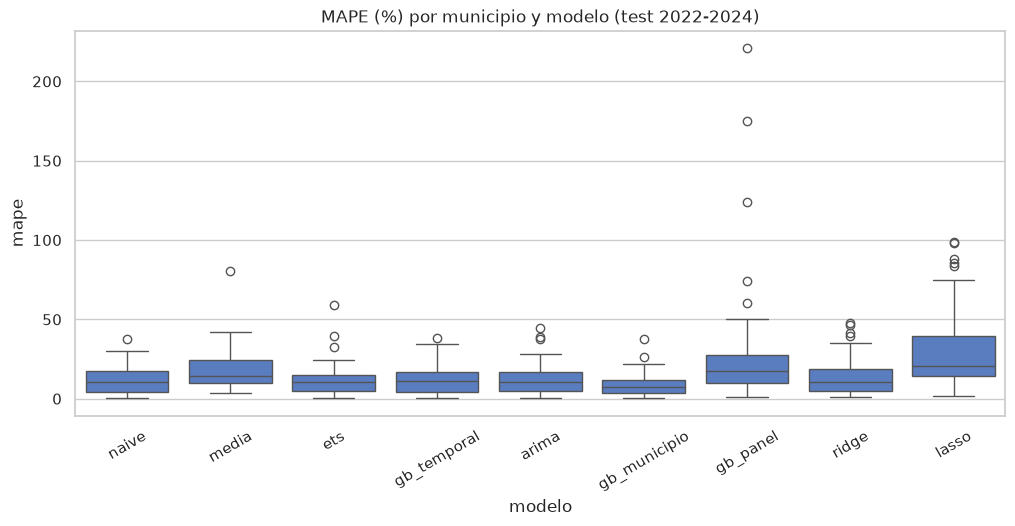

In [3]:
# ── Distribucion del MAPE por modelo
plt.figure(figsize=(12, 5))
sns.boxplot(data=res, x="modelo", y="mape")
plt.title("MAPE (%) por municipio y modelo (test 2022-2024)")
plt.xticks(rotation=30)
plt.show()


In [4]:
# ── Mejor modelo por municipio (min MAPE)
best = res.loc[res.groupby("cod_municipio")["mape"].idxmin()]
print(best.groupby("modelo").size().rename("municipios ganados").sort_values(ascending=False))


modelo
gb_municipio    14
ridge           14
gb_panel        12
gb_temporal      8
naive            7
arima            6
lasso            4
ets              2
Name: municipios ganados, dtype: int64


In [5]:
# ── Rendimiento por tamano de municipio (consumo medio en test)
DATA = Path("data")
import polars as pl
abast = pl.read_csv(DATA / "abastecimiento_urbano_baleares.csv", infer_schema_length=None).select(["cod_municipio", "anio", "consumo_hm3"])
consumo_test = (abast.filter(pl.col("anio") >= 2022)
                .group_by("cod_municipio").agg(pl.col("consumo_hm3").mean().alias("consumo_medio_hm3"))
                .to_pandas())
cmp = res.merge(consumo_test, on="cod_municipio")
cmp["tamano"] = pd.qcut(cmp["consumo_medio_hm3"], 3, labels=["pequeno", "mediano", "grande"])
piv = cmp.pivot_table(index="modelo", columns="tamano", values="mape", aggfunc="mean").round(1)
piv[["pequeno", "mediano", "grande"]]


tamano,pequeno,mediano,grande
modelo,,,
arima,7.7,11.1,17.9
ets,8.0,11.0,16.1
gb_municipio,7.3,10.5,8.4
gb_panel,48.4,16.7,11.5
gb_temporal,7.4,11.6,16.5
lasso,54.5,19.2,14.5
media,17.8,19.9,15.6
naive,7.8,10.7,16.3
ridge,12.8,16.3,11.7


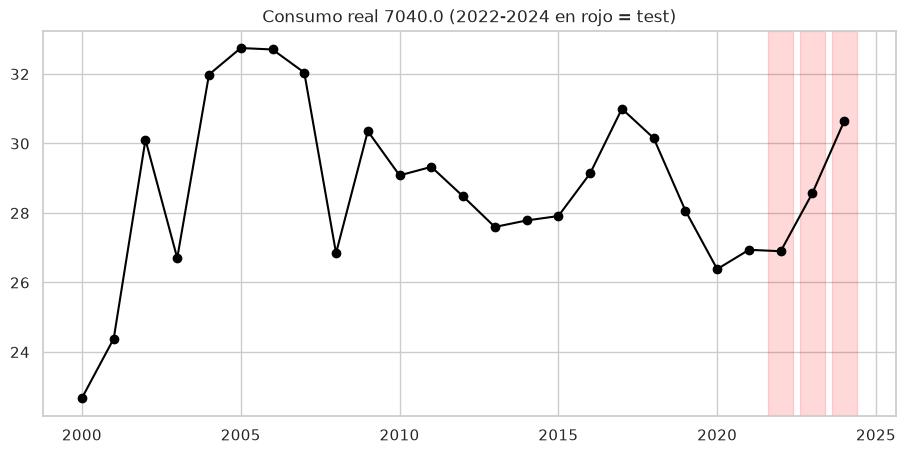

               mape   mae
modelo                   
naive          5.99  1.79
media          4.55  1.30
ets            6.68  1.99
gb_temporal    5.72  1.71
arima          5.99  1.79
gb_municipio   3.63  1.07
gb_panel       2.91  0.84
ridge         11.52  3.41
lasso          8.44  2.51


In [6]:
# ── Ejemplo: Palma (municipio de mayor consumo) — actual vs predicciones
palma = consumo_test.sort_values("consumo_medio_hm3", ascending=False).iloc[0]
cod_palma = palma["cod_municipio"]

abast_p = (abast.filter(pl.col("cod_municipio") == cod_palma)
           .sort("anio").select(["anio", "consumo_hm3"]).to_pandas())
plt.figure(figsize=(11, 5))
plt.plot(abast_p["anio"], abast_p["consumo_hm3"], "o-", label="real", color="black")
for modelo in res["modelo"].unique():
    m = res[(res["modelo"] == modelo) & (res["cod_municipio"] == cod_palma)]
    # los errores agregados no permiten reconstruir la serie; mostramos el MAPE del municipio
plt.title(f"Consumo real {cod_palma} (2022-2024 en rojo = test)")
for a in [2022, 2023, 2024]:
    plt.axvspan(a - 0.4, a + 0.4, color="red", alpha=0.15)
plt.show()
print(res[res["cod_municipio"] == cod_palma].set_index("modelo")[["mape", "mae"]].round(2))


**Conclusiones**

- Si los modelos con features (gb_municipio / gb_panel / ridge-lasso) no mejoran a `naive`/`media`, el consumo anual por municipio es dificil de predecir con estas covariadas (inercia fuerte + ruido).
- Ver `municipios ganados` por modelo y la tabla por tamano: los modelos complejos suelen aportar mas en municipios grandes (mas senal en IPH/ocupacion).
- Siguiente paso natural: probar horizonte 1 anio (test solo 2024), features de balance hidrico, o modelo por isla.
